<a href="https://colab.research.google.com/github/rajnish80130/Real-state-Capstone-Project/blob/main/feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [4]:
df=pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,la vida by tata housing,sector 113,3.00,14286.0,3,3,3+,3.0,Relatively New,2460.0,0,1,0,0,0,0,167
1,flat,umang monsoon breeze,sector 78,0.88,4746.0,3,4,3,8.0,Moderately Old,1668.0,0,1,0,1,0,0,111
2,flat,ireo the grand arch,sector 58,4.85,16934.0,4,5,3,23.0,Relatively New,3182.0,1,1,0,1,1,2,49
3,flat,m3m woodshire,sector 107,1.49,6311.0,3,4,3+,5.0,Relatively New,2137.0,0,1,1,0,0,2,174
4,flat,ambience creacions,sector 22,6.16,20533.0,4,5,3+,10.0,New Property,3333.0,0,1,0,1,0,2,49


In [5]:
df.shape

(3553, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3553 non-null   object 
 1   society          3553 non-null   object 
 2   sector           3553 non-null   object 
 3   price            3553 non-null   float64
 4   price_per_sqft   3553 non-null   float64
 5   bedRoom          3553 non-null   int64  
 6   bathroom         3553 non-null   int64  
 7   balcony          3553 non-null   object 
 8   floorNum         3553 non-null   float64
 9   agePossession    3553 non-null   object 
 10  built_up_area    3553 non-null   float64
 11  study room       3553 non-null   int64  
 12  servant room     3553 non-null   int64  
 13  store room       3553 non-null   int64  
 14  pooja room       3553 non-null   int64  
 15  others           3553 non-null   int64  
 16  furnishing_type  3553 non-null   int64  
 17  luxury_score  

In [7]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [8]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 113,3.00,3,3,3+,3.0,Relatively New,2460.0,0,1,0,0,0,0,167
1,flat,sector 78,0.88,3,4,3,8.0,Moderately Old,1668.0,0,1,0,1,0,0,111
2,flat,sector 58,4.85,4,5,3,23.0,Relatively New,3182.0,1,1,0,1,1,2,49
3,flat,sector 107,1.49,3,4,3+,5.0,Relatively New,2137.0,0,1,1,0,0,2,174
4,flat,sector 22,6.16,4,5,3+,10.0,New Property,3333.0,0,1,0,1,0,2,49


In [9]:
train_df.shape

(3553, 16)

### luxury score

<Axes: ylabel='luxury_score'>

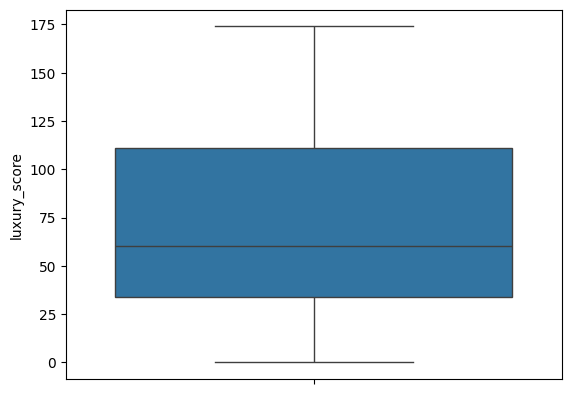

In [10]:
sns.boxplot(df['luxury_score'])

In [11]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [12]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [13]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 113,3.00,3,3,3+,3.0,Relatively New,2460.0,0,1,0,0,0,0,167,High
1,flat,sector 78,0.88,3,4,3,8.0,Moderately Old,1668.0,0,1,0,1,0,0,111,Medium
2,flat,sector 58,4.85,4,5,3,23.0,Relatively New,3182.0,1,1,0,1,1,2,49,Low
3,flat,sector 107,1.49,3,4,3+,5.0,Relatively New,2137.0,0,1,1,0,0,2,174,High
4,flat,sector 22,6.16,4,5,3+,10.0,New Property,3333.0,0,1,0,1,0,2,49,Low


## floorNum

<Axes: ylabel='floorNum'>

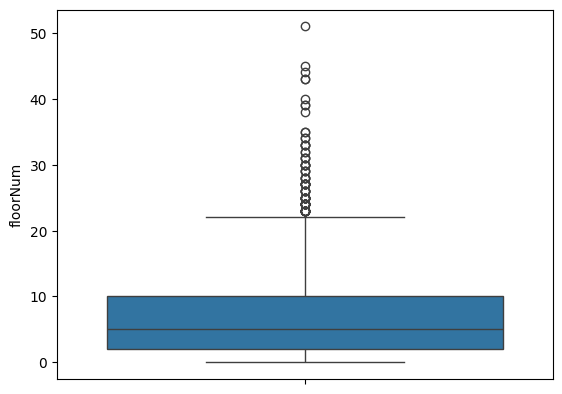

In [14]:
sns.boxplot(df['floorNum'])

In [15]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [16]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [17]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 113,3.00,3,3,3+,3.0,Relatively New,2460.0,0,1,0,0,0,0,167,High,Mid Floor
1,flat,sector 78,0.88,3,4,3,8.0,Moderately Old,1668.0,0,1,0,1,0,0,111,Medium,Mid Floor
2,flat,sector 58,4.85,4,5,3,23.0,Relatively New,3182.0,1,1,0,1,1,2,49,Low,High Floor
3,flat,sector 107,1.49,3,4,3+,5.0,Relatively New,2137.0,0,1,1,0,0,2,174,High,Mid Floor
4,flat,sector 22,6.16,4,5,3+,10.0,New Property,3333.0,0,1,0,1,0,2,49,Low,Mid Floor


In [18]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [19]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 113,3.00,3,3,3+,Relatively New,2460.0,0,1,0,0,0,0,High,Mid Floor
1,flat,sector 78,0.88,3,4,3,Moderately Old,1668.0,0,1,0,1,0,0,Medium,Mid Floor
2,flat,sector 58,4.85,4,5,3,Relatively New,3182.0,1,1,0,1,1,2,Low,High Floor
3,flat,sector 107,1.49,3,4,3+,Relatively New,2137.0,0,1,1,0,0,2,High,Mid Floor
4,flat,sector 22,6.16,4,5,3+,New Property,3333.0,0,1,0,1,0,2,Low,Mid Floor


In [20]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [21]:
X_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,17.0,3,3,4.0,3.0,2460.0,0,1,0,0,0,0,0.0,2.0
1,0.0,88.0,3,4,3.0,0.0,1668.0,0,1,0,1,0,0,2.0,2.0
2,0.0,65.0,4,5,3.0,3.0,3182.0,1,1,0,1,1,2,1.0,0.0
3,0.0,9.0,3,4,4.0,3.0,2137.0,0,1,1,0,0,2,0.0,2.0
4,0.0,27.0,4,5,4.0,1.0,3333.0,0,1,0,1,0,2,1.0,2.0


In [22]:
y_label.head()

,price
0,3.00
1,0.88
2,4.85
3,1.49
4,6.16


## Technique 1 - Correlation Analysis

<Axes: >

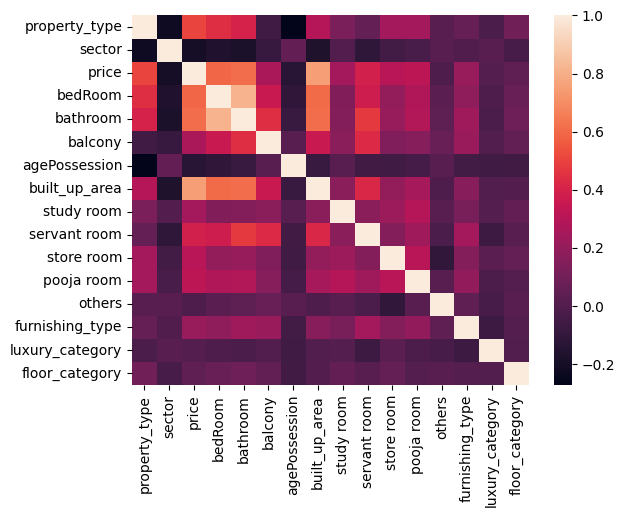

In [23]:
sns.heatmap(data_label_encoded.corr())

In [24]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'}).sort_values('corr_coeff',ascending=False)
fi_df1

,feature,corr_coeff
1,price,1.000000
6,built_up_area,0.748637
3,bathroom,0.610325
2,bedRoom,0.591296
8,servant room,0.391881
10,pooja room,0.319815
9,store room,0.305651
4,balcony,0.269582
7,study room,0.242911
12,furnishing_type,0.214360


## Technique 2 - Random Forest Feature Importance

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.649713
1,sector,0.105950
0,property_type,0.102438
2,bedRoom,0.025403
3,bathroom,0.025303
8,servant room,0.021997
5,agePossession,0.013496
4,balcony,0.012960
12,furnishing_type,0.007412
13,luxury_category,0.007352


## Technique 3 - Gradient Boosting Feature importances

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.685071
1,sector,0.102705
0,property_type,0.095331
2,bedRoom,0.036910
3,bathroom,0.035240
8,servant room,0.020966
9,store room,0.009776
5,agePossession,0.005005
7,study room,0.004264
12,furnishing_type,0.001442


# Technique 4 - Permutation Importance

In [27]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.723539
0,property_type,0.222261
1,sector,0.191449
2,bedRoom,0.013699
8,servant room,0.012122
3,bathroom,0.011807
5,agePossession,0.006077
4,balcony,0.005977
13,luxury_category,0.001691
14,floor_category,0.001538


## Technique 5 - LASSO

In [28]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.510720
0,property_type,0.713212
3,bathroom,0.279116
9,store room,0.198886
7,study room,0.175325
8,servant room,0.166656
12,furnishing_type,0.138028
10,pooja room,0.074915
13,luxury_category,0.051058
2,bedRoom,0.018588


## Technique 6 - RFE

In [29]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.652263
1,sector,0.102950
0,property_type,0.102917
3,bathroom,0.024549
2,bedRoom,0.023775
8,servant room,0.020337
5,agePossession,0.014571
4,balcony,0.012748
7,study room,0.010990
13,luxury_category,0.007013


## Technique 7 - Linear Regression Weights

In [30]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.513384
0,property_type,0.714455
3,bathroom,0.285173
9,store room,0.203143
7,study room,0.183254
8,servant room,0.176320
12,furnishing_type,0.147503
10,pooja room,0.077794
13,luxury_category,0.062658
2,bedRoom,0.021816


## Technique 8 - SHAP

In [31]:
!pip install shap

In [35]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-0.40969888,  0.19652677, -0.04395317, ..., -0.02973436,
         0.00483454, -0.0782082 ],
       [-0.22950168, -0.35430408, -0.02089078, ..., -0.01121779,
        -0.02311277, -0.0135446 ],
       [-1.27808925,  0.74834319, -0.04014874, ...,  0.02678858,
        -0.00310957,  0.01883225],
       ...,
       [-0.42643842,  0.18324444,  0.01168091, ...,  0.05912879,
         0.00255581,  0.24382265],
       [-0.17725686, -0.30750138, -0.06157141, ...,  0.01511681,
         0.00720911, -0.00595851],
       [-0.4583732 , -0.71072096,  0.01955507, ..., -0.01310043,
        -0.0058283 , -0.01102895]])

In [36]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.246486
0,property_type,0.474587
1,sector,0.381969
3,bathroom,0.113535
8,servant room,0.104814
2,bedRoom,0.058954
4,balcony,0.041062
5,agePossession,0.026426
14,floor_category,0.023893
12,furnishing_type,0.018015


In [37]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [38]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
built_up_area,0.748637,0.649713,0.685071,0.723539,1.510720,0.652263,1.513384,1.246486
bathroom,0.610325,0.025303,0.035240,0.011807,0.279116,0.024549,0.285173,0.113535
bedRoom,0.591296,0.025403,0.036910,0.013699,0.018588,0.023775,0.021816,0.058954
servant room,0.391881,0.021997,0.020966,0.012122,0.166656,0.020337,0.176320,0.104814
pooja room,0.319815,0.005531,0.000000,-0.000111,0.074915,0.006219,0.077794,0.011549
store room,0.305651,0.006540,0.009776,-0.001059,0.198886,0.005469,0.203143,0.014142
balcony,0.269582,0.012960,0.001269,0.005977,-0.045078,0.012748,-0.068080,0.041062
study room,0.242911,0.006775,0.004264,-0.002026,0.175325,0.010990,0.183254,0.015933
furnishing_type,0.214360,0.007412,0.001442,-0.000632,0.138028,0.007001,0.147503,0.018015


In [39]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [40]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.711514
sector,0.145685
bathroom,0.032260
bedRoom,0.027627
servant room,0.026657
balcony,0.011196
agePossession,0.011162
study room,0.006013
store room,0.005977


In [42]:
# to drop pooja room, study room, others
X_label.head(10)

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,17.0,3,3,4.0,3.0,2460.0,0,1,0,0,0,0,0.0,2.0
1,0.0,88.0,3,4,3.0,0.0,1668.0,0,1,0,1,0,0,2.0,2.0
2,0.0,65.0,4,5,3.0,3.0,3182.0,1,1,0,1,1,2,1.0,0.0
3,0.0,9.0,3,4,4.0,3.0,2137.0,0,1,1,0,0,2,0.0,2.0
4,0.0,27.0,4,5,4.0,1.0,3333.0,0,1,0,1,0,2,1.0,2.0
5,0.0,89.0,2,2,4.0,3.0,1494.0,1,0,0,0,0,0,2.0,2.0
6,0.0,78.0,3,3,2.0,3.0,1428.0,0,0,0,1,0,2,0.0,2.0
7,0.0,101.0,3,3,2.0,1.0,1581.0,0,0,0,0,0,0,1.0,1.0
8,0.0,63.0,3,3,3.0,2.0,1810.0,0,1,0,0,0,2,2.0,2.0
9,1.0,74.0,5,6,4.0,3.0,3150.0,0,1,1,0,0,2,0.0,2.0


In [43]:
X_label.shape

(3553, 15)

In [44]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [45]:
scores.mean()

np.float64(0.8006142334392843)

In [46]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [47]:
scores.mean()

np.float64(0.8032338132082633)

In [48]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [50]:
export_df.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,17.0,3,3,4.0,3.0,2460.0,1,0,0,0.0,2.0,3.00
1,0.0,88.0,3,4,3.0,0.0,1668.0,1,0,0,2.0,2.0,0.88
2,0.0,65.0,4,5,3.0,3.0,3182.0,1,0,2,1.0,0.0,4.85
3,0.0,9.0,3,4,4.0,3.0,2137.0,1,1,2,0.0,2.0,1.49
4,0.0,27.0,4,5,4.0,1.0,3333.0,1,0,2,1.0,2.0,6.16


In [52]:
export_df.shape

(3553, 13)

In [53]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)